In [161]:
# create a new CSV with totals by person

import pandas as pd

# set paths
input_csv = "loan_office_certificates_cleaned.csv"
output_csv = "by_person_total_loan_office_certificates.csv"

# read CSV
df = pd.read_csv(input_csv, usecols=["raw_name", "raw_name_state", "Face Value", "Specie Value"], low_memory=False)

# group by raw_name_state and sum values and sort 
summed = df.groupby(["raw_name", "raw_name_state"])[["Face Value", "Specie Value"]].sum().reset_index()

print(summed)
summed.to_csv(output_csv, index=False)

                                raw_name  \
0      A AND J J CALDWELL FOR EVMITCHELL   
1                                A INMAN   
2                            A VOEROSSON   
3                          AANS MORRISON   
4                           AARON AUSTIN   
...                                  ...   
18115                        ZILLAH GILL   
18116                   ZIPORAH RICHARDS   
18117                   ZIPORAH WILLIAMS   
18118                     ZOPHAS HATHEWA   
18119                      ZUANS PEARCEL   

                              raw_name_state  Face Value  Specie Value  
0      A AND J J CALDWELL FOR EVMITCHELL||PA        2000       50.0000  
1                                A INMAN||PA        1800      206.3499  
2                            A VOEROSSON||PA       10600      483.7721  
3                          AANS MORRISON||PA        7000     2312.0419  
4                           AARON AUSTIN||NJ        3700      180.0667  
...                              

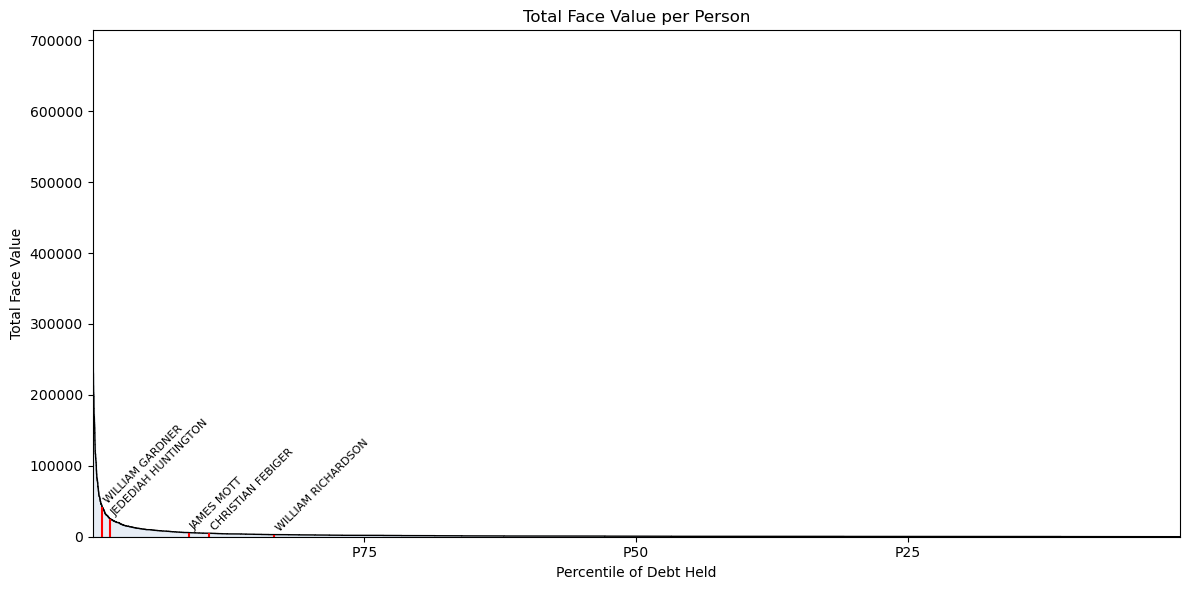

In [172]:
# full size graph for Face Value
import matplotlib.pyplot as plt

# sort by Face Value
sorted_data_face = summed.sort_values("Face Value", ascending=False).reset_index()

# set axis
x=range(len(sorted_data_face))
y=sorted_data_face["Face Value"]

# plot
plt.figure(figsize=(12, 6))
plt.step(x, y, where="mid", color="black", linewidth=1)
plt.fill_between(x, y, step='mid', alpha=0.3, color="lightsteelblue")

#label x axis
percentiles = [75, 50, 25]
percentile_positions = [int(((100-p)) / 100 * (len(sorted_data_face) - 1)) for p in percentiles]
percentile_labels = [f"P{p}" for p in percentiles]
plt.xticks(percentile_positions, percentile_labels)
plt.xlabel("Percentile of Debt Held")
plt.xlim(0, len(sorted_data_face))

# label y axis
plt.ylabel("Total Face Value")
plt.ylim(0,)


# names to search
treasurer_names = [
    "JAMES MOTT",
    "JEDEDIAH HUNTINGTON",
    "CHRISTIAN FEBIGER",
    "WILLIAM GARDNER",
    "WILLIAM RICHARDSON"
]

# create vertical bars & labels
highlight_indices = sorted_data_face[sorted_data_face["raw_name"].isin(treasurer_names)].index.tolist()
for idx in highlight_indices:
    name = sorted_data_face.loc[idx, "raw_name"]
    value = y[idx]
    plt.vlines(idx, 0, value, color='red', linewidth=1.5)
    plt.text(idx, value + 1000, name, rotation=45, ha="left", va="bottom", fontsize=8)

# final formatting & show
plt.title("Total Face Value per Person")
plt.tight_layout()
plt.show()

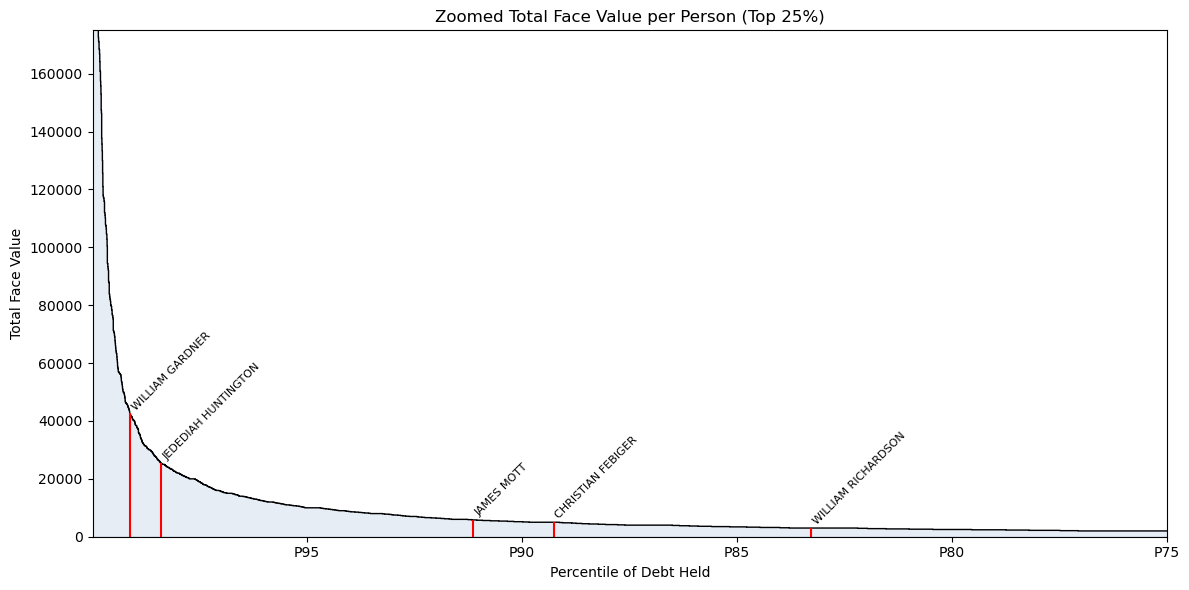

In [173]:
# zoomed graph

# set axis
x=range(len(sorted_data_face))
y=sorted_data_face["Face Value"]

# plot
plt.figure(figsize=(12, 6))
plt.step(x, y, where="mid", color="black", linewidth=1)
plt.fill_between(x, y, step='mid', alpha=0.3, color="lightsteelblue")

#label x axis
percentiles = [95, 90, 85, 80, 75]
percentile_positions = [int(((100-p)) / 100 * (len(sorted_data_face) - 1)) for p in percentiles]
percentile_labels = [f"P{p}" for p in percentiles]
plt.xticks(percentile_positions, percentile_labels)
plt.xlabel("Percentile of Debt Held")
plt.xlim(0, len(sorted_data_face)/4)

# label y axis
plt.ylabel("Total Face Value")
plt.ylim(0, 175000)


# names to search
treasurer_names = [
    "JAMES MOTT",
    "JEDEDIAH HUNTINGTON",
    "CHRISTIAN FEBIGER",
    "WILLIAM GARDNER",
    "WILLIAM RICHARDSON"
]

# create vertical bars & labels
highlight_indices = sorted_data_face[sorted_data_face["raw_name"].isin(treasurer_names)].index.tolist()
for idx in highlight_indices:
    name = sorted_data_face.loc[idx, "raw_name"]
    value = y[idx]
    plt.vlines(idx, 0, value, color='red', linewidth=1.5)
    plt.text(idx, value + 500, name, rotation=45, ha="left", va="bottom", fontsize=8)

# final formatting & show
plt.title("Zoomed Total Face Value per Person (Top 25%)")
plt.tight_layout()
plt.show()

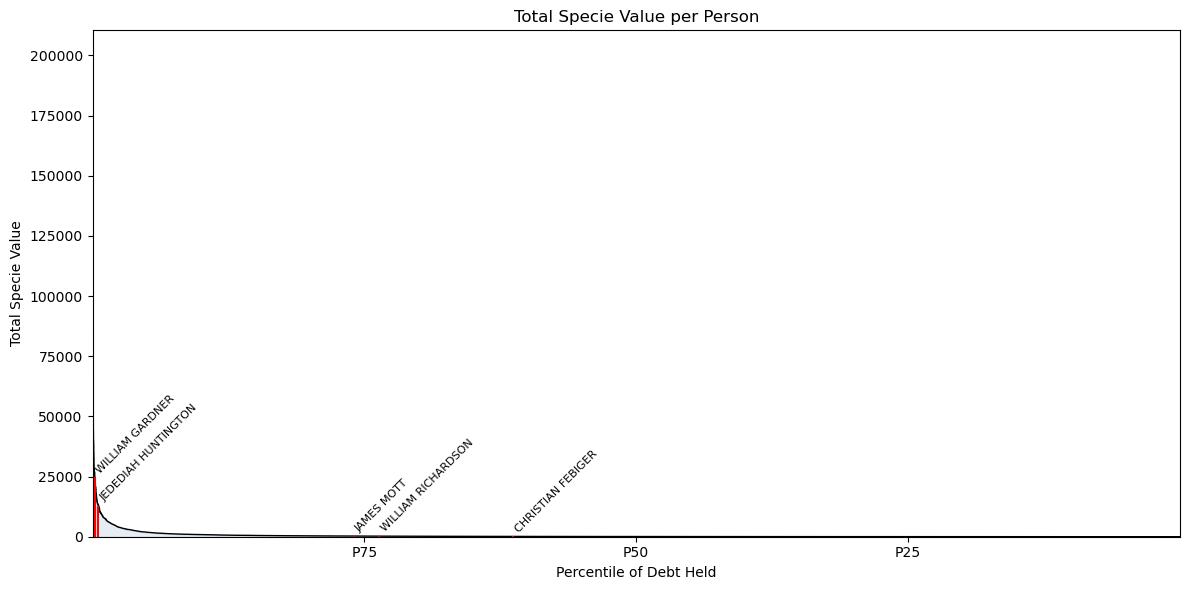

In [174]:
# full size graph for Specie Value
import matplotlib.pyplot as plt

# sort by Specie Value
sorted_data_specie = summed.sort_values("Specie Value", ascending=False).reset_index()

# set axis
x=range(len(sorted_data))
y=sorted_data_specie["Specie Value"]

# plot
plt.figure(figsize=(12, 6))
plt.step(x, y, where="mid", color="black", linewidth=1)
plt.fill_between(x, y, step='mid', alpha=0.3, color="lightsteelblue")

#label x axis
percentiles = [75, 50, 25]
percentile_positions = [int(((100-p)) / 100 * (len(sorted_data) - 1)) for p in percentiles]
percentile_labels = [f"P{p}" for p in percentiles]
plt.xticks(percentile_positions, percentile_labels)
plt.xlabel("Percentile of Debt Held")
plt.xlim(0, len(sorted_data))

# label y axis
plt.ylabel("Total Specie Value")
plt.ylim(0,)


# names to search
treasurer_names = [
    "JAMES MOTT",
    "JEDEDIAH HUNTINGTON",
    "CHRISTIAN FEBIGER",
    "WILLIAM GARDNER",
    "WILLIAM RICHARDSON"
]

# create vertical bars & labels
highlight_indices = sorted_data_specie[sorted_data_specie["raw_name"].isin(treasurer_names)].index.tolist()
for idx in highlight_indices:
    name = sorted_data_specie.loc[idx, "raw_name"]
    value = y[idx]
    plt.vlines(idx, 0, value, color='red', linewidth=1.5)
    plt.text(idx, value + 1000, name, rotation=45, ha="left", va="bottom", fontsize=8)

# final formatting & show
plt.title("Total Specie Value per Person")
plt.tight_layout()
plt.show()

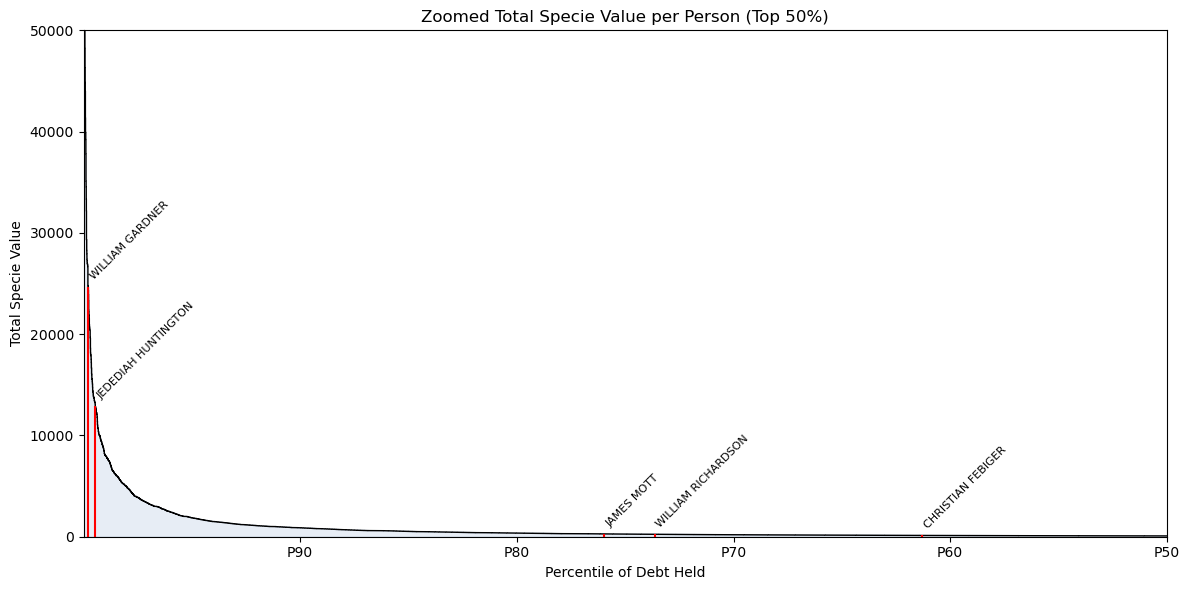

In [175]:
# zoomed graph for Specie Value
import matplotlib.pyplot as plt

# set axis
x=range(len(sorted_data_specie))
y=sorted_data_specie["Specie Value"]

# plot
plt.figure(figsize=(12, 6))
plt.step(x, y, where="mid", color="black", linewidth=1)
plt.fill_between(x, y, step='mid', alpha=0.3, color="lightsteelblue")

#label x axis
percentiles = [90, 80, 70, 60, 50]
percentile_positions = [int(((100-p)) / 100 * (len(sorted_data_specie) - 1)) for p in percentiles]
percentile_labels = [f"P{p}" for p in percentiles]
plt.xticks(percentile_positions, percentile_labels)
plt.xlabel("Percentile of Debt Held")
plt.xlim(0, len(sorted_data_specie)/2)

# label y axis
plt.ylabel("Total Specie Value")
plt.ylim(0, 50000)


# names to search
treasurer_names = [
    "JAMES MOTT",
    "JEDEDIAH HUNTINGTON",
    "CHRISTIAN FEBIGER",
    "WILLIAM GARDNER",
    "WILLIAM RICHARDSON"
]

# create vertical bars & labels
highlight_indices = sorted_data_specie[sorted_data_specie["raw_name"].isin(treasurer_names)].index.tolist()
for idx in highlight_indices:
    name = sorted_data_specie.loc[idx, "raw_name"]
    value = y[idx]
    plt.vlines(idx, 0, value, color='red', linewidth=1.5)
    plt.text(idx, value + 500, name, rotation=45, ha="left", va="bottom", fontsize=8)

# final formatting & show
plt.title("Zoomed Total Specie Value per Person (Top 50%)")
plt.tight_layout()
plt.show()

In [171]:
# calculate and print percentile ranks for selected treasurers
print("Treasurer Percentile Ranks:\n")

treasurer_names = [
    "JAMES MOTT",
    "JEDEDIAH HUNTINGTON",
    "CHRISTIAN FEBIGER",
    "WILLIAM GARDNER",
    "WILLIAM RICHARDSON"
]

for name in treasurer_names:
    match = sorted_data_face[sorted_data_face["raw_name"] == name]
    if not match.empty:
        idx = match.index[0]
        percentile = 100 * idx / (len(sorted_data_face) - 1)
        face_value = match["Face Value"].values[0]
        print(f"{name:<25} — Index: {idx:<4}  Percentile: {100-percentile:.2f}%  Face Value: {face_value:,.2f}")
    else:
        print(f"{name:<25} — Not found in data.")

Treasurer Percentile Ranks:

JAMES MOTT                — Index: 1605  Percentile: 91.14%  Face Value: 5,800.00
JEDEDIAH HUNTINGTON       — Index: 290   Percentile: 98.40%  Face Value: 25,400.00
CHRISTIAN FEBIGER         — Index: 1944  Percentile: 89.27%  Face Value: 5,000.00
WILLIAM GARDNER           — Index: 158   Percentile: 99.13%  Face Value: 42,600.00
WILLIAM RICHARDSON        — Index: 3029  Percentile: 83.28%  Face Value: 3,000.00


In [168]:
for name in treasurer_names:
    match = sorted_data_specie[sorted_data_specie["raw_name"] == name]
    if not match.empty:
        idx = match.index[0]
        percentile = 100 * idx / (len(sorted_data_specie) - 1)
        specie_value = match["Specie Value"].values[0]
        print(f"{name:<25} — Index: {idx:<4}  Percentile: {100-percentile:.2f}%  Specie Value: {specie_value:,.2f}")
    else:
        print(f"{name:<25} — Not found in data.")

JAMES MOTT                — Index: 4352  Percentile: 75.98%  Specie Value: 277.17
JEDEDIAH HUNTINGTON       — Index: 98    Percentile: 99.46%  Specie Value: 12,860.93
CHRISTIAN FEBIGER         — Index: 7013  Percentile: 61.29%  Specie Value: 125.00
WILLIAM GARDNER           — Index: 38    Percentile: 99.79%  Specie Value: 24,671.11
WILLIAM RICHARDSON        — Index: 4776  Percentile: 73.64%  Specie Value: 237.63
